## Feature Extraction, Clustering, and Dimensionality Reduction using PCA

In this section, we will perform feature extraction and clustering on our dataset. Additionally, we will use Principal Component Analysis (PCA) to reduce the dimensionality of the data.

Our data consists of signals captured by devices, which may contain noise. Therefore, we will create two datasets:
1. Dataset without using the Butterworth lowpass filter
2. Dataset using the Butterworth lowpass filter

We will then evaluate which dataset performs better in modeling.

In [555]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helper.tools import LowPassFilter, PrincipalComponentAnalysis
from sklearn.cluster import KMeans


# plot settings
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams["lines.linewidth"] = 2


In [556]:
# load data
df = pd.read_pickle('../processed_data/dataInterpolated.pkl')
columns = list(df.columns[1:7])
columns

['Accelerometer_x',
 'Accelerometer_y',
 'Accelerometer_z',
 'Gyroscope_x',
 'Gyroscope_y',
 'Gyroscope_z']

**No Filtering**

- PCA

In [557]:
columns

['Accelerometer_x',
 'Accelerometer_y',
 'Accelerometer_z',
 'Gyroscope_x',
 'Gyroscope_y',
 'Gyroscope_z']

In [558]:
PCA = PrincipalComponentAnalysis()
df_pca_NoFilter = df.copy()

values = PCA.determine_pc_explained_variance(df_pca_NoFilter, columns)
values

array([0.50790737, 0.26920756, 0.089986  , 0.07003222, 0.03980249,
       0.02306436])

- Elbow Method

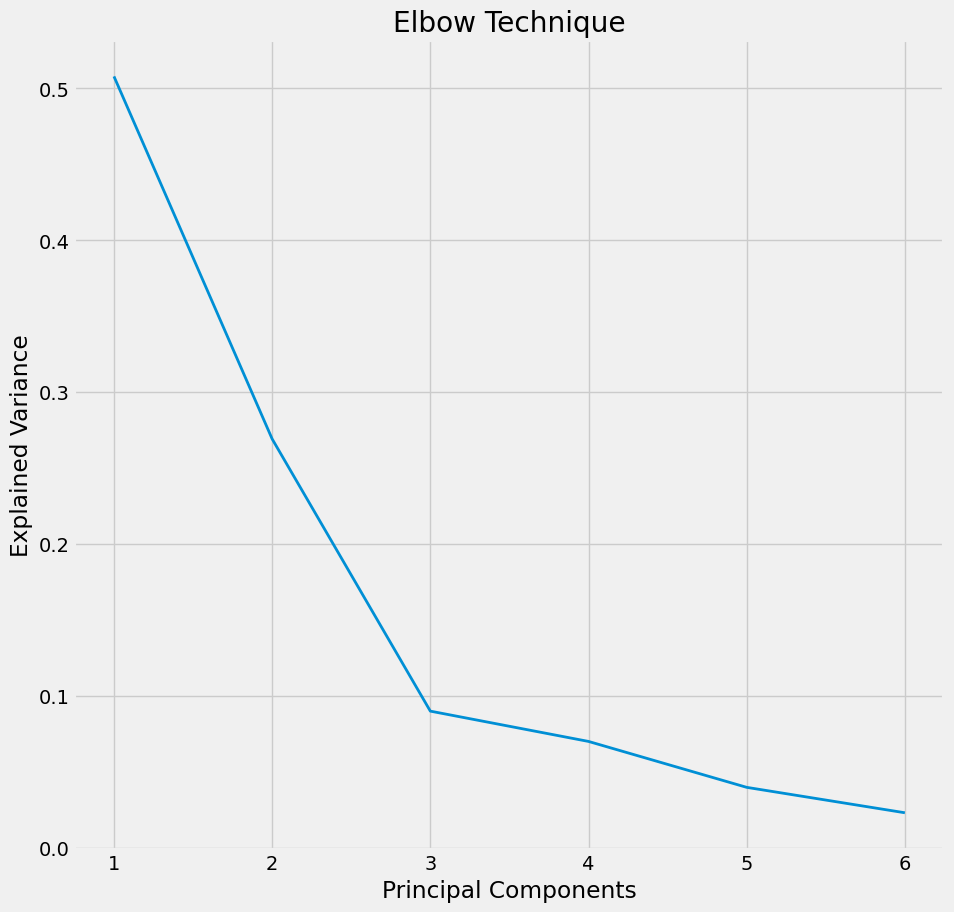

In [559]:
# ELBOW TECHNIQUE

plt.figure(figsize=(10, 10))
plt.plot(range(1, len(columns) + 1), values)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Elbow Technique")
plt.show()

In [560]:
# apply pca on 3 components
df_pca_NoFilter = PCA.apply_pca(df_pca_NoFilter, columns, 3)
df_pca_NoFilter.head()

,epoch (ms),Accelerometer_x,Accelerometer_y,Accelerometer_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,Participants,Label,Category,Set,pca_1,pca_2,pca_3
0,2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30,0.286293,-0.061765,0.001397
1,2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30,0.286233,-0.069850,-0.002455
2,2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30,0.285532,-0.060637,0.026497
3,2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30,0.283898,-0.071333,0.050818
4,2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30,0.286172,-0.094813,0.032053


- plot the 3 pca

<Axes: >

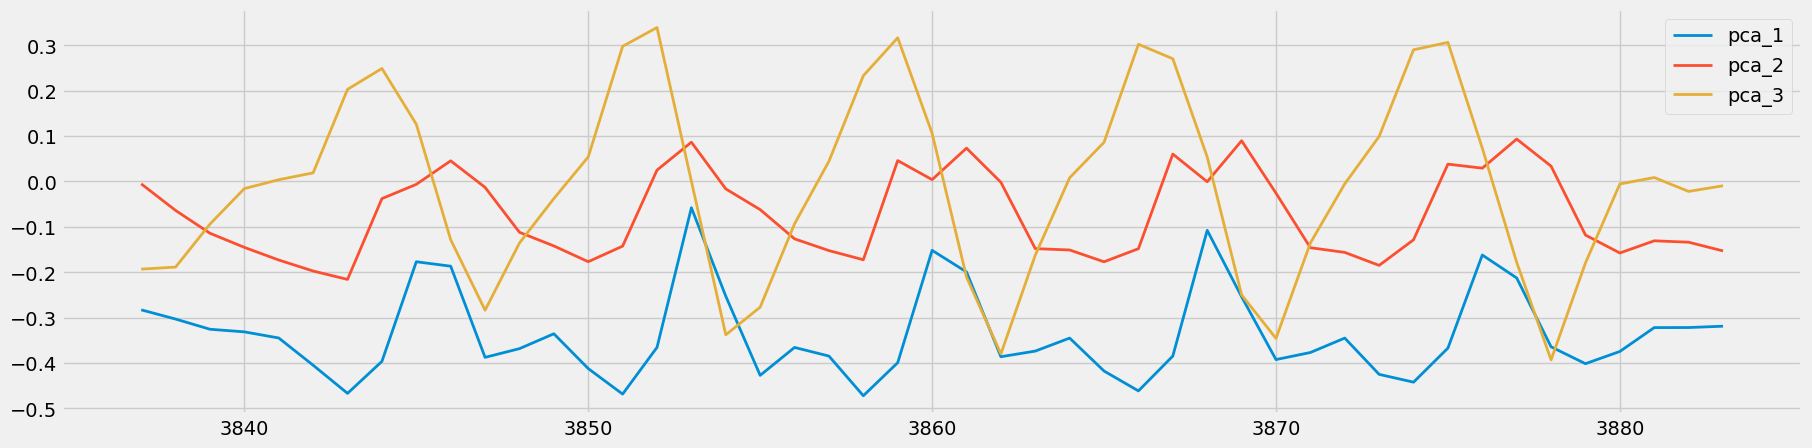

In [561]:
subset = df_pca_NoFilter[df_pca_NoFilter["Set"] == 35]
subset[["pca_1", "pca_2", "pca_3"]].plot()
# in this case wee see that the data have noise

- Applying squares feature extraction using the squares formula
Formula: $\text{feature}^2$

In [562]:
df_squered_NoFilter = df_pca_NoFilter.copy()
Accelerometer_r = df_squered_NoFilter["Accelerometer_x"]**2 + df_squered_NoFilter["Accelerometer_y"]**2 + df_squered_NoFilter["Accelerometer_z"]**2
Gyroscope_r = df_squered_NoFilter["Gyroscope_x"]**2 + df_squered_NoFilter["Gyroscope_y"]**2 + df_squered_NoFilter["Gyroscope_z"]**2

df_squered_NoFilter["Accelerometer_r"] = np.sqrt(Accelerometer_r)
df_squered_NoFilter["Gyroscope_r"] = np.sqrt(Gyroscope_r)

df_squered_NoFilter.head()


,epoch (ms),Accelerometer_x,Accelerometer_y,Accelerometer_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,Participants,Label,Category,Set,pca_1,pca_2,pca_3,Accelerometer_r,Gyroscope_r
0,2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30,0.286293,-0.061765,0.001397,0.979669,3.225625
1,2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30,0.286233,-0.069850,-0.002455,0.973752,2.887270
2,2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30,0.285532,-0.060637,0.026497,0.973795,2.936720
3,2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30,0.283898,-0.071333,0.050818,0.960118,9.473502
4,2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30,0.286172,-0.094813,0.032053,0.964953,4.623585


- ploting the Accelerometer_r and Gyroscope_r

array([<Axes: >, <Axes: >], dtype=object)

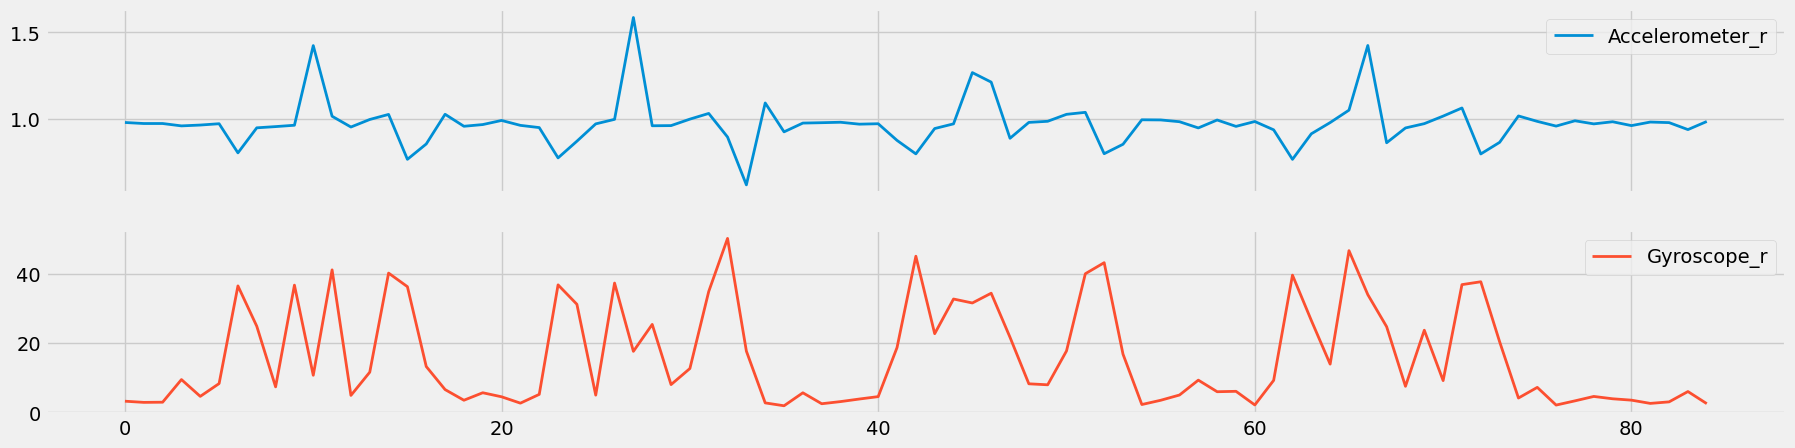

In [563]:
subset = df_squered_NoFilter[df_squered_NoFilter["Set"] == 30]
subset[["Accelerometer_r", "Gyroscope_r"]].plot(subplots=True)

- Clastering

In [564]:
df_cluster_NoFilter = df_squered_NoFilter.copy()
columns = ["Accelerometer_x", "Accelerometer_y", 'Accelerometer_z']
kvalues = range(1, 10)
inertia = []

for k in kvalues:
    subset = df_cluster_NoFilter[columns]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) # fit_predict is used to fit the model and predict the cluster labels
    inertia.append(kmeans.inertia_) # inertia is the sum of squared distances of samples to their closest cluster center


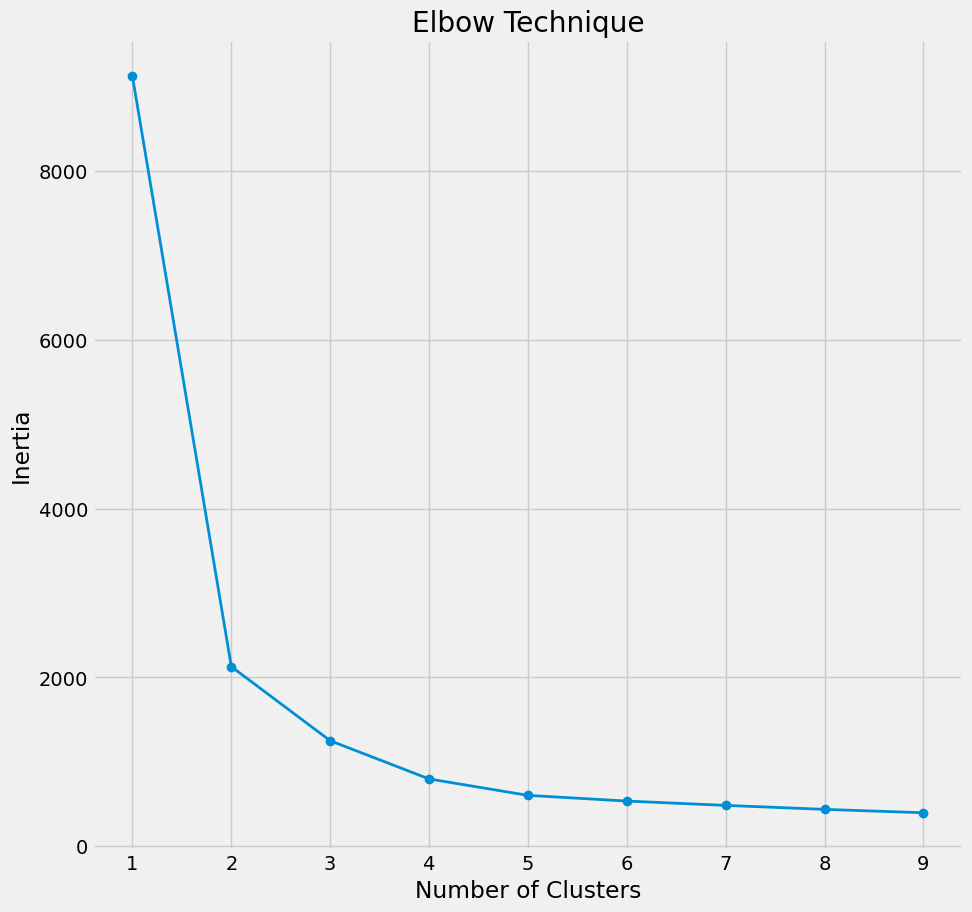

In [565]:
# lest use the list to plot the elbow method
plt.figure(figsize=(10, 10))
plt.plot(kvalues, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique")
plt.show()

In [566]:
# in this case is between 4 and 5 I will use 5
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster_NoFilter[columns]
df_cluster_NoFilter["cluster"] = kmeans.fit_predict(subset)
df_cluster_NoFilter.head()


,epoch (ms),Accelerometer_x,Accelerometer_y,Accelerometer_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,Participants,Label,Category,Set,pca_1,pca_2,pca_3,Accelerometer_r,Gyroscope_r,cluster
0,2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30,0.286293,-0.061765,0.001397,0.979669,3.225625,2
1,2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30,0.286233,-0.069850,-0.002455,0.973752,2.887270,2
2,2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30,0.285532,-0.060637,0.026497,0.973795,2.936720,2
3,2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30,0.283898,-0.071333,0.050818,0.960118,9.473502,2
4,2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30,0.286172,-0.094813,0.032053,0.964953,4.623585,2


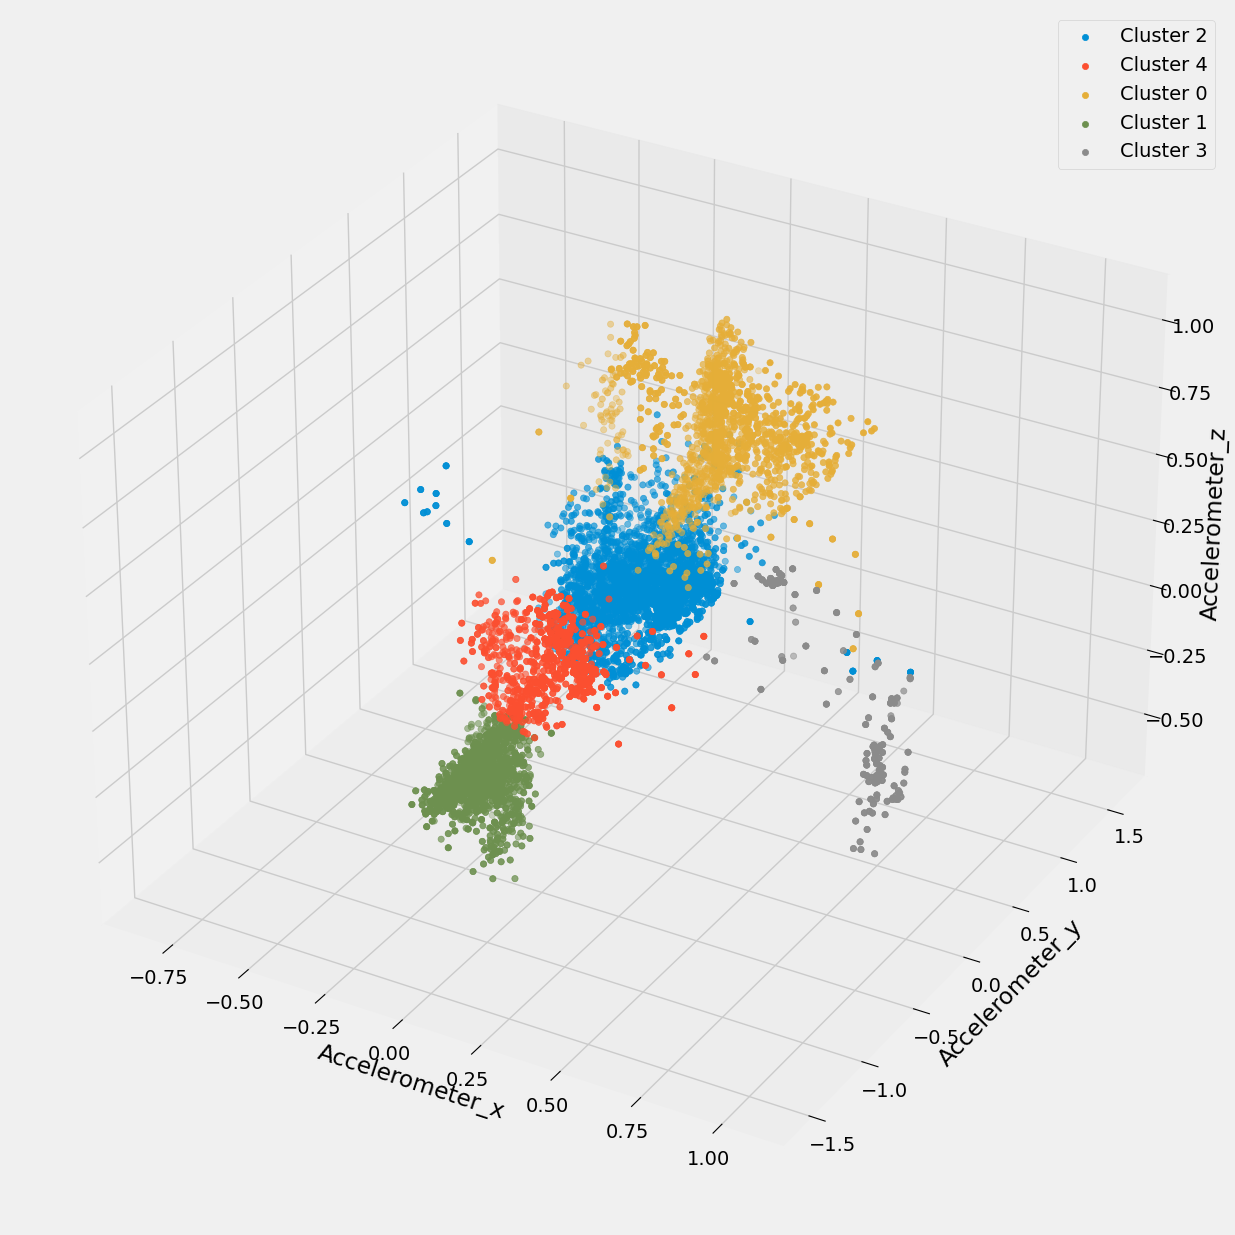

In [567]:
# plot the clusters
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')
for c in df_cluster_NoFilter["cluster"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
plt.legend()
plt.show()

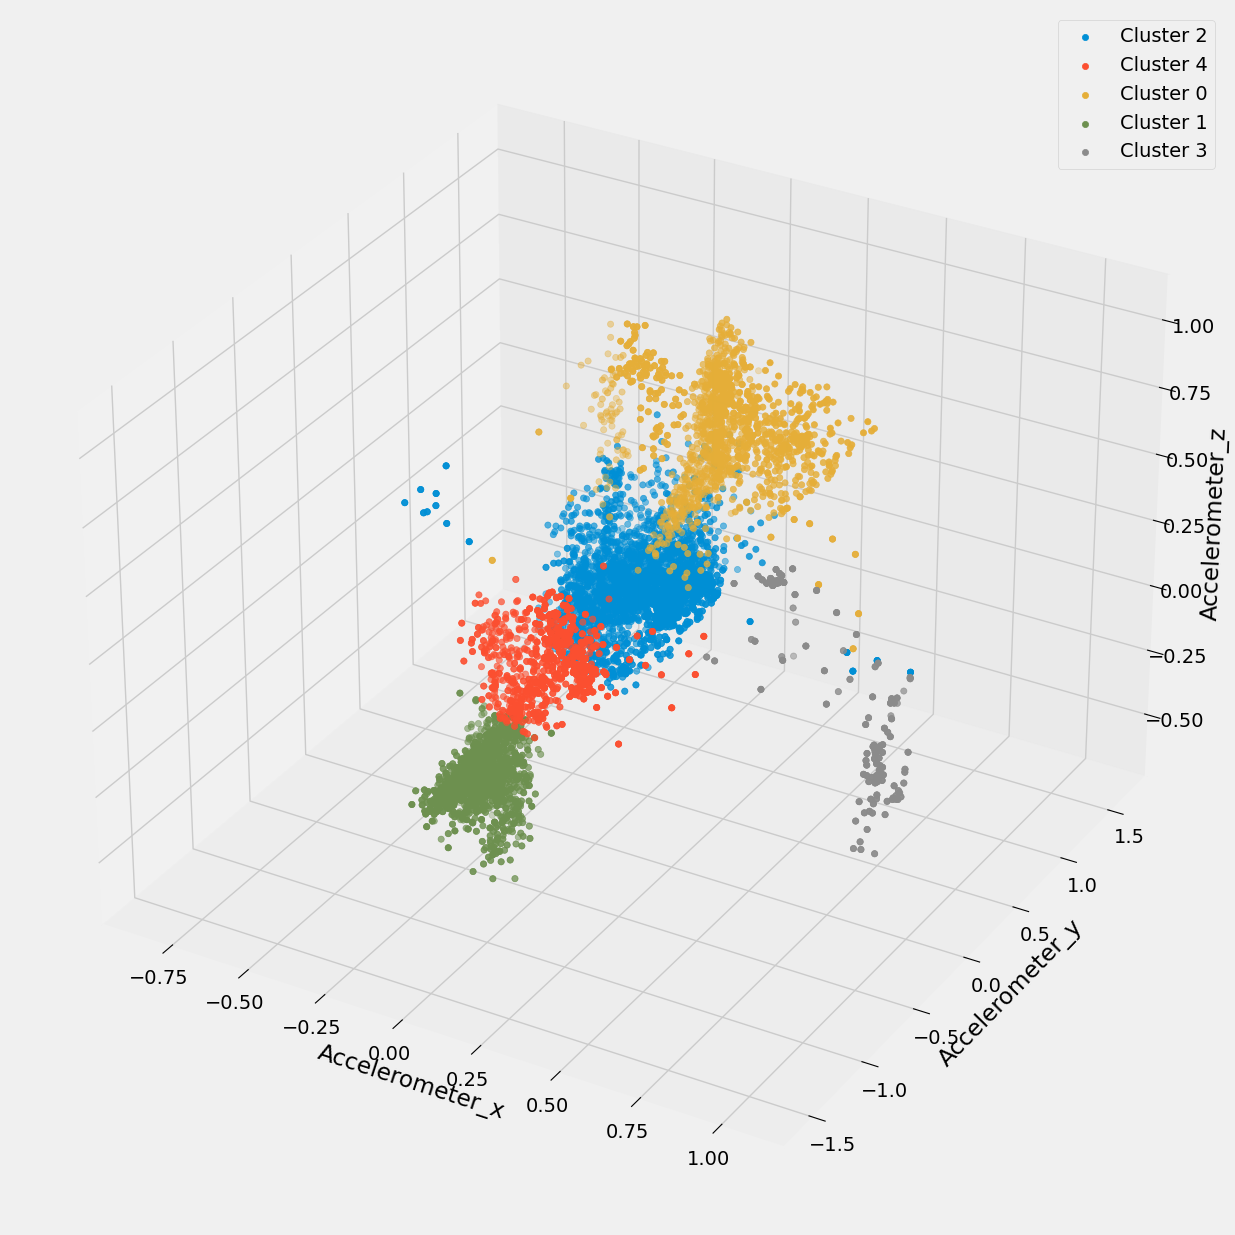

In [568]:
# plotting by unique cluster
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')
for c in df_cluster_NoFilter["cluster"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
plt.legend()
plt.show()

- In the end we see that we have noise in this clusterng

#### **Filtering the dataset**

- We will use a low pass filter to remove the noise

In [569]:
df_filter = df.copy()
columns = list(df.columns[1:7])
LowPass = LowPassFilter()
df_filter

,epoch (ms),Accelerometer_x,Accelerometer_y,Accelerometer_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,Participants,Label,Category,Set
0,2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30
1,2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30
2,2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30
3,2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30
4,2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30
...,...,...,...,...,...,...,...,...,...,...,...
9004,2019-01-20 17:33:27.000,-0.048000,-1.041500,-0.076500,1.4146,-5.6218,0.2926,E,row,medium,40
9005,2019-01-20 17:33:27.200,-0.037000,-1.030333,-0.053333,-2.7684,-0.5854,2.2440,E,row,medium,40
9006,2019-01-20 17:33:27.400,-0.060000,-1.031000,-0.082000,2.8416,-5.1342,-0.1220,E,row,medium,40
9007,2019-01-20 17:33:27.600,-0.038667,-1.025667,-0.044667,-0.2318,0.2562,1.1220,E,row,medium,40


In [570]:
# wee see that the device is based on 200 ms
# so to for one second = 1000 ms
# 1000/200 = 5 smaples so the frequency is 5

fs = 1000/200
cutoff = 0.8 # how many hz we want to keep

# let's apply this filter to one column and see the result
df_filter = LowPass.low_pass_filter(df_filter, "Accelerometer_y", fs, cutoff, order=5)


squat


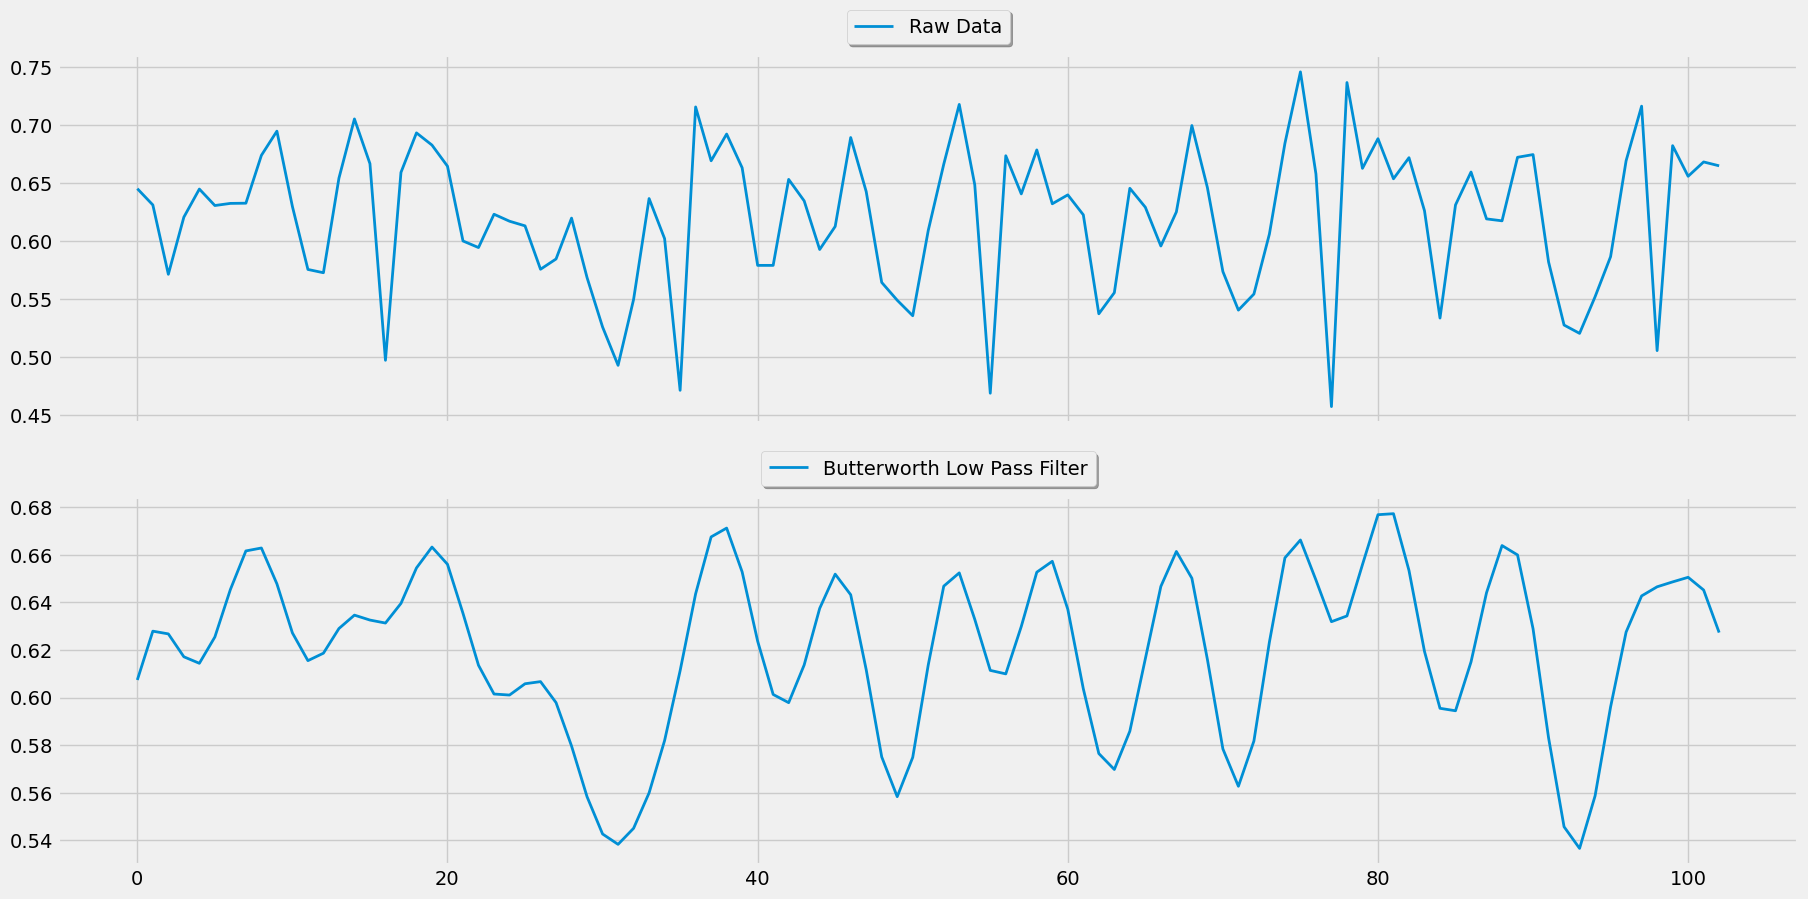

In [571]:
# we see clearly that the data is smoother and less noise
subset = df_filter[df_filter["Set"] == 45]
print(subset["Label"].iloc[0])

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))
ax[0].plot(subset["Accelerometer_y"].reset_index(drop=True), label="Raw Data")
ax[1].plot(subset["Accelerometer_y_lowpass"].reset_index(drop=True), label="Butterworth Low Pass Filter")
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)
plt.show()

In [572]:
# apply the filter to all columns
for col in columns:
    df_filter = LowPass.low_pass_filter(df_filter, col, fs, cutoff, order=5)
    df_filter[col] = df_filter[col + "_lowpass"] # overwriting the original column with the low pass filter column
    df_filter.drop(columns=[col + "_lowpass"], inplace=True) # drop the low pass filter column

- PCA

In [573]:
PCA = PrincipalComponentAnalysis()
df_pca_Filter = df_filter.copy()

values = PCA.determine_pc_explained_variance(df_pca_Filter, columns)
values

array([0.550892  , 0.24042966, 0.09048544, 0.05979065, 0.04006526,
       0.01833699])

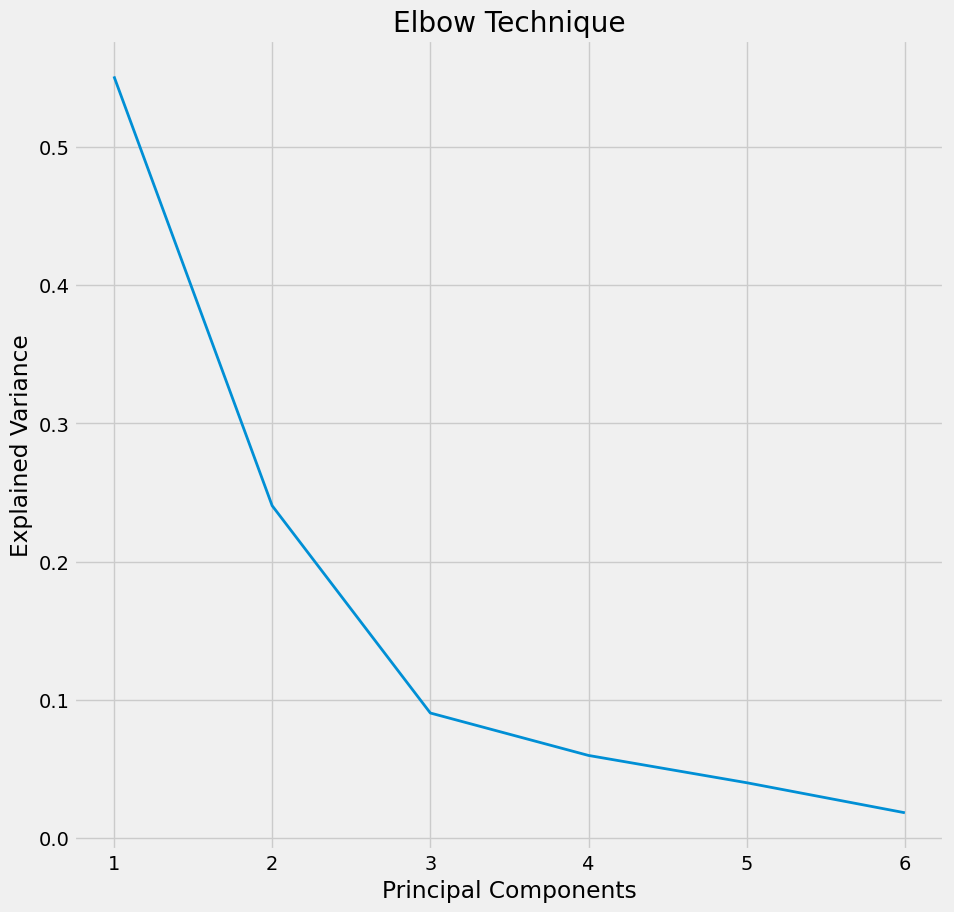

In [574]:
# ELBOW TECHNIQUE

plt.figure(figsize=(10, 10))
plt.plot(range(1, len(columns) + 1), values)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Elbow Technique")
plt.show()

In [575]:
# apply pca on 3 components
df_pca_Filter = PCA.apply_pca(df_pca_Filter, columns, 3)
df_pca_Filter.head()

,epoch (ms),Accelerometer_x,Accelerometer_y,Accelerometer_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,Participants,Label,Category,Set,pca_1,pca_2,pca_3
0,2019-01-11 15:08:05.200,0.013535,0.977182,-0.070960,-1.902101,2.434810,0.948936,B,bench,heavy,30,0.333472,-0.072804,-0.016723
1,2019-01-11 15:08:05.400,0.001894,0.988682,-0.063015,-1.833784,-1.425162,2.956037,B,bench,heavy,30,0.338546,-0.070207,-0.021360
2,2019-01-11 15:08:05.600,-0.004295,0.990923,-0.061879,0.208787,-3.046921,2.093641,B,bench,heavy,30,0.339626,-0.070653,-0.001703
3,2019-01-11 15:08:05.800,-0.007274,0.974049,-0.074569,4.639898,-1.630084,-2.601024,B,bench,heavy,30,0.333476,-0.079016,0.048221
4,2019-01-11 15:08:06.000,-0.017437,0.934461,-0.104489,9.564729,1.590182,-9.275511,B,bench,heavy,30,0.320152,-0.099647,0.107359


- plot the 3 pca

<Axes: >

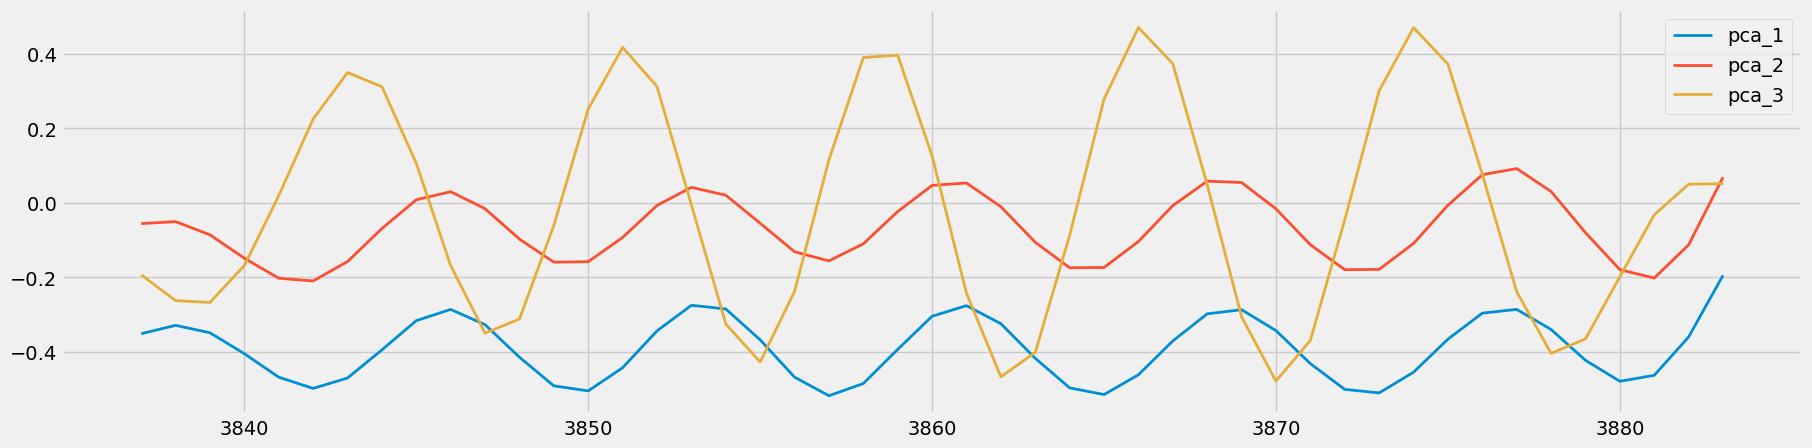

In [576]:
subset = df_pca_Filter[df_pca_Filter["Set"] == 35]
subset[["pca_1", "pca_2", "pca_3"]].plot()

- squerd

In [577]:
df_squered_Filter = df_pca_Filter.copy()
Accelerometer_r = df_squered_Filter["Accelerometer_x"]**2 + df_squered_Filter["Accelerometer_y"]**2 + df_squered_Filter["Accelerometer_z"]**2
Gyroscope_r = df_squered_Filter["Gyroscope_x"]**2 + df_squered_Filter["Gyroscope_y"]**2 + df_squered_Filter["Gyroscope_z"]**2

df_squered_Filter["Accelerometer_r"] = np.sqrt(Accelerometer_r)
df_squered_Filter["Gyroscope_r"] = np.sqrt(Gyroscope_r)

array([<Axes: >, <Axes: >], dtype=object)

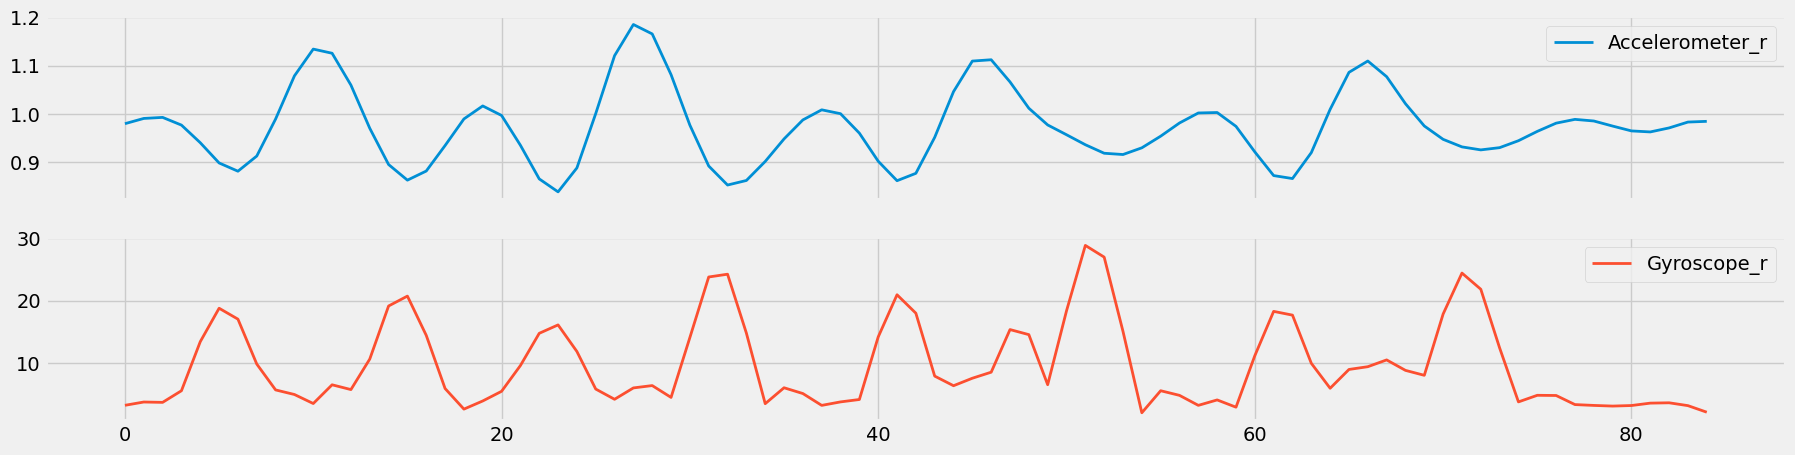

In [578]:
subset = df_squered_Filter[df_squered_Filter["Set"] == 30]
subset[["Accelerometer_r", "Gyroscope_r"]].plot(subplots=True)

- clastering

In [579]:
df_cluster_Filter = df_squered_Filter.copy()
columns = ["Accelerometer_x", "Accelerometer_y", 'Accelerometer_z']
kvalues = range(1, 10)
inertia = []

for k in kvalues:
    subset = df_cluster_Filter[columns]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) # fit_predict is used to fit the model and predict the cluster labels
    inertia.append(kmeans.inertia_) # inertia is the sum of squared distances of samples to their closest cluster center

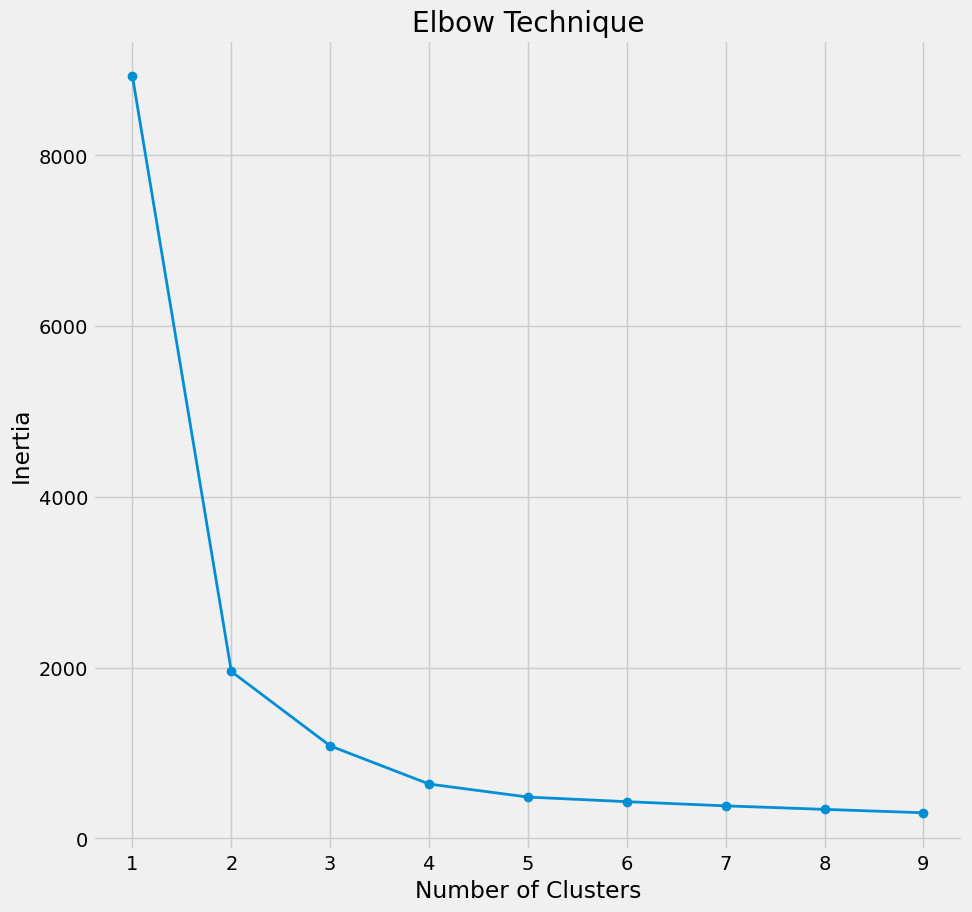

In [580]:
# lest use the list to plot the elbow method
plt.figure(figsize=(10, 10))
plt.plot(kvalues, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique")
plt.show()

In [581]:
# in this case is between 4 and 5 I will use 5
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster_Filter[columns]
df_cluster_Filter["cluster"] = kmeans.fit_predict(subset)
df_cluster_Filter.head()

,epoch (ms),Accelerometer_x,Accelerometer_y,Accelerometer_z,Gyroscope_x,Gyroscope_y,Gyroscope_z,Participants,Label,Category,Set,pca_1,pca_2,pca_3,Accelerometer_r,Gyroscope_r,cluster
0,2019-01-11 15:08:05.200,0.013535,0.977182,-0.070960,-1.902101,2.434810,0.948936,B,bench,heavy,30,0.333472,-0.072804,-0.016723,0.979849,3.232145,2
1,2019-01-11 15:08:05.400,0.001894,0.988682,-0.063015,-1.833784,-1.425162,2.956037,B,bench,heavy,30,0.338546,-0.070207,-0.021360,0.990690,3.759255,2
2,2019-01-11 15:08:05.600,-0.004295,0.990923,-0.061879,0.208787,-3.046921,2.093641,B,bench,heavy,30,0.339626,-0.070653,-0.001703,0.992862,3.702790,2
3,2019-01-11 15:08:05.800,-0.007274,0.974049,-0.074569,4.639898,-1.630084,-2.601024,B,bench,heavy,30,0.333476,-0.079016,0.048221,0.976927,5.563376,2
4,2019-01-11 15:08:06.000,-0.017437,0.934461,-0.104489,9.564729,1.590182,-9.275511,B,bench,heavy,30,0.320152,-0.099647,0.107359,0.940446,13.418190,2


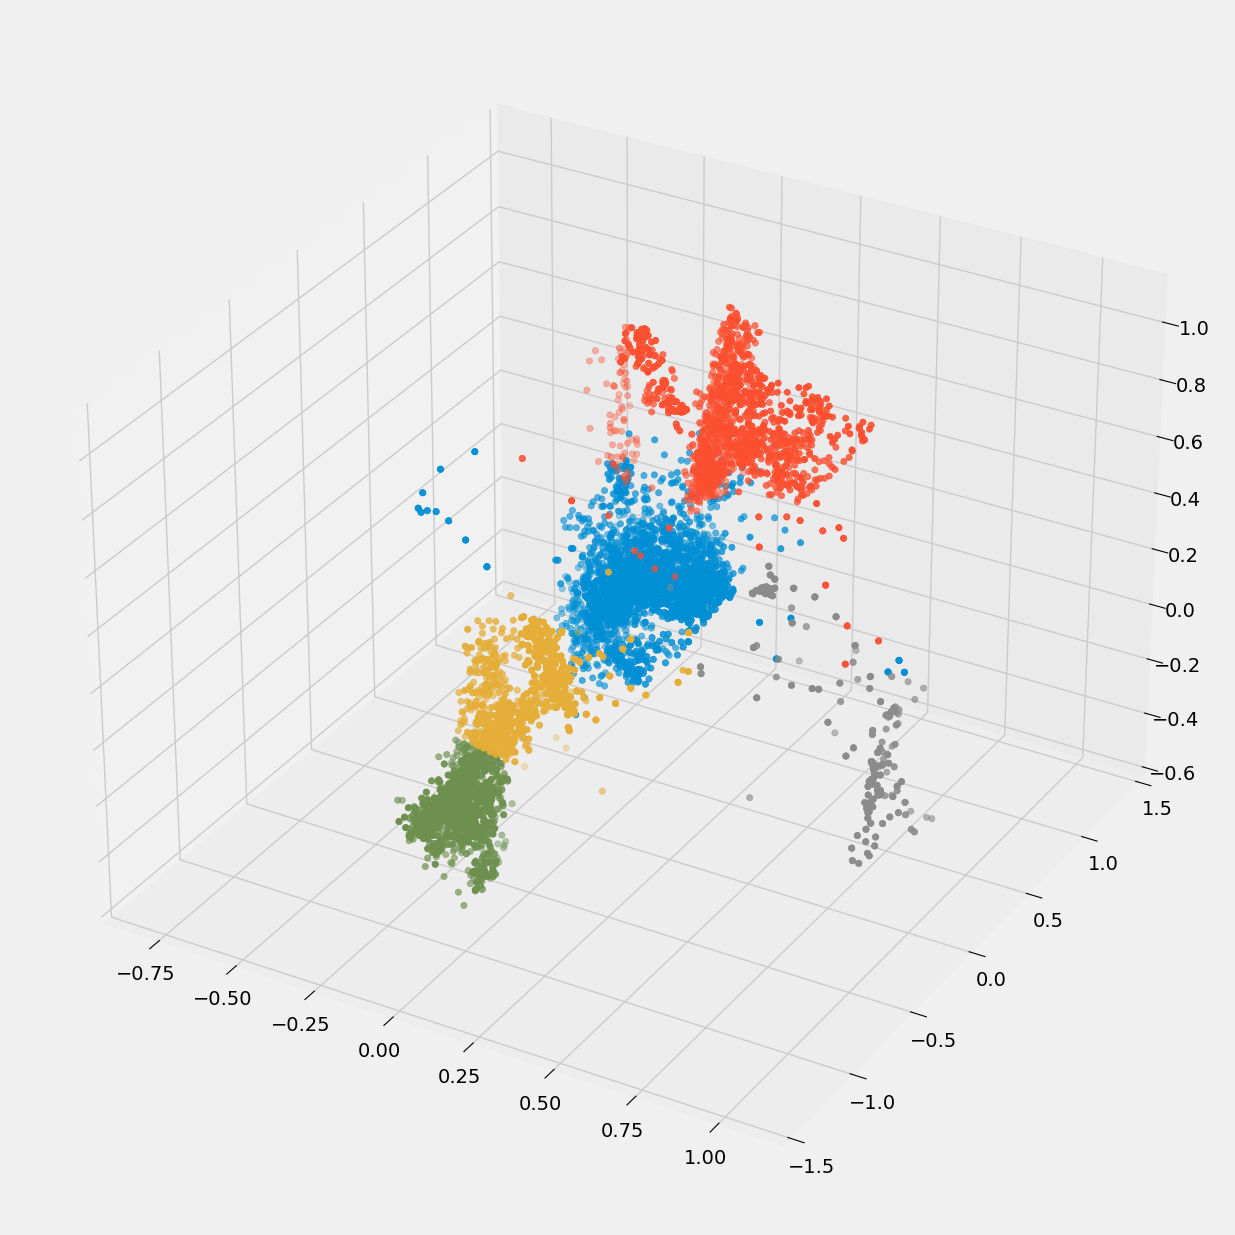

In [582]:

# plot the clusters
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')
for c in df_cluster_Filter["cluster"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")

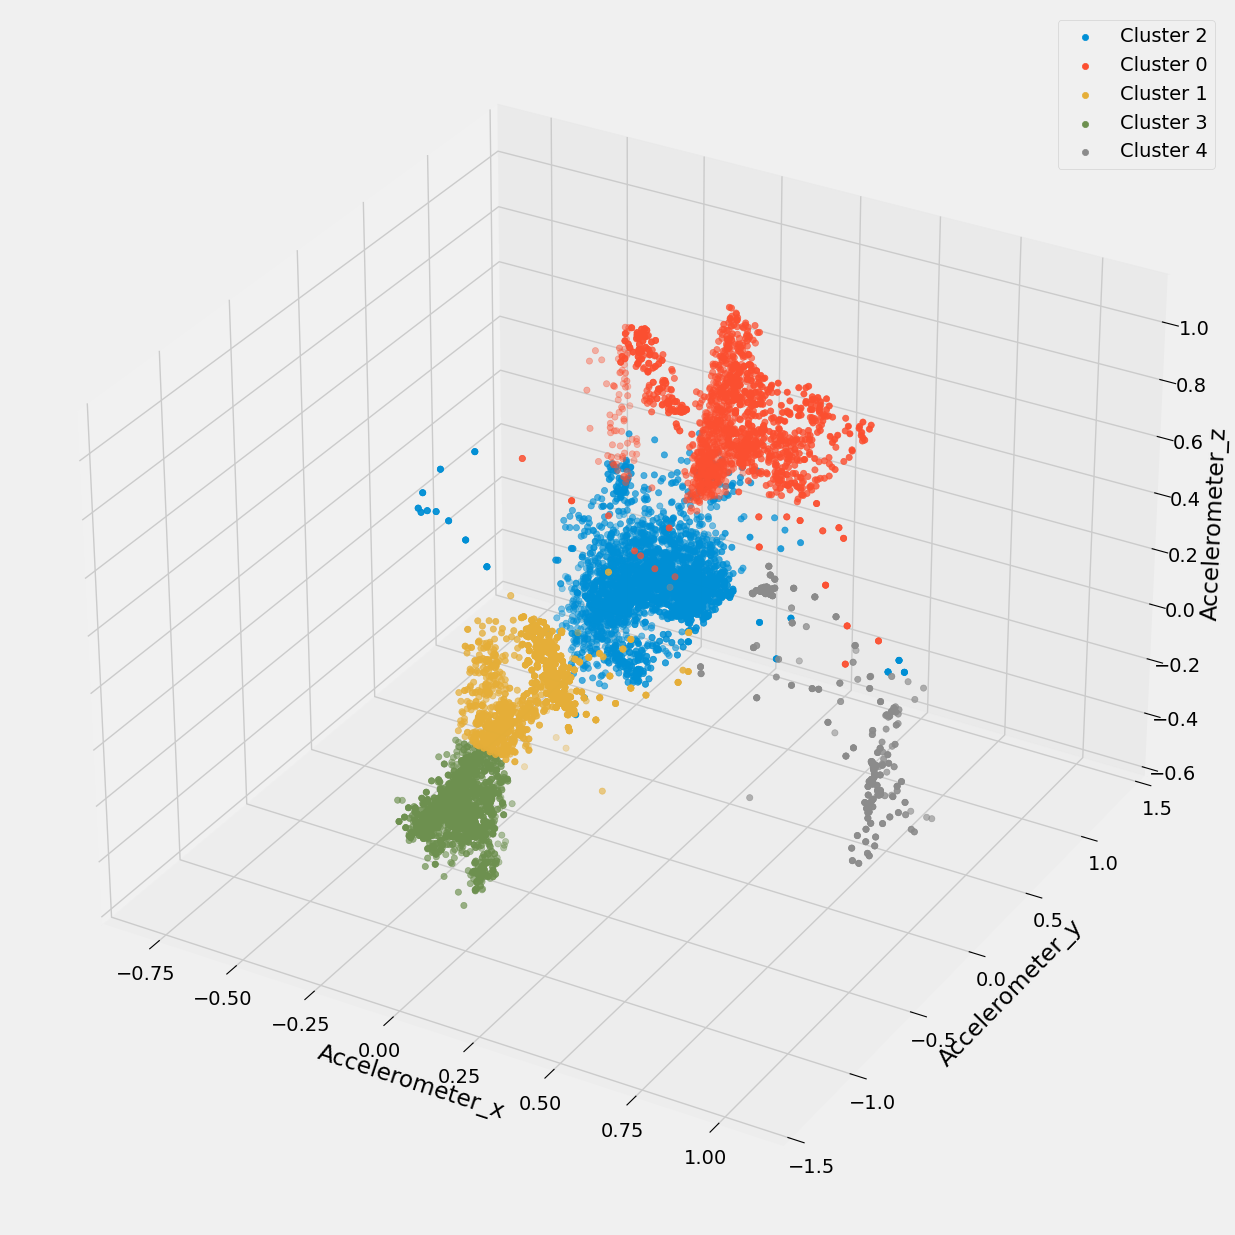

In [583]:
# plot the clusters
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')

for c in df_cluster_Filter["cluster"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
plt.legend()
plt.show()

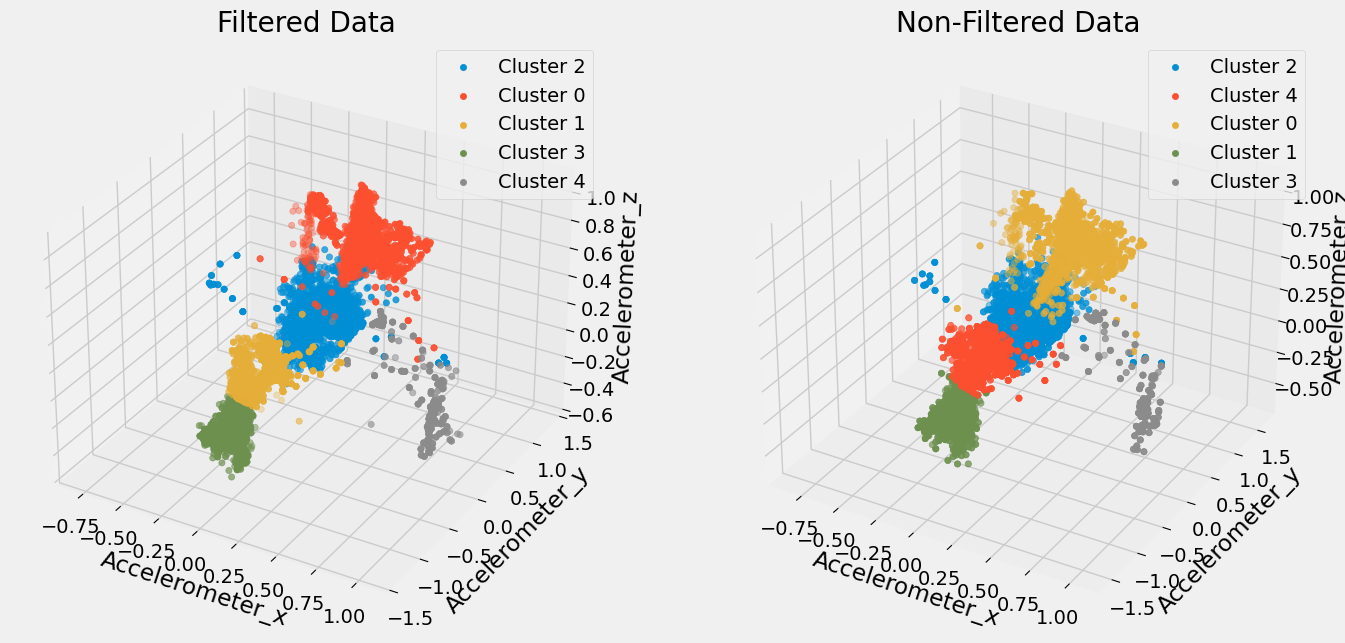

In [586]:
# plot the clusters for filtered data
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(121, projection='3d')
for c in df_cluster_Filter["cluster"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Filtered Data")
plt.legend()

# plot the clusters for non-filtered data
ax = fig.add_subplot(122, projection='3d')
for c in df_cluster_NoFilter["cluster"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Non-Filtered Data")
plt.legend()

plt.show()


In [ ]:
# save the dasets
#df_pca_NoFilter.to_pickle("../processed_data/dataPCA_NoFilter.pkl")
#df_pca_Filter.to_pickle("../processed_data/dataPCA_Filter.pkl")